18


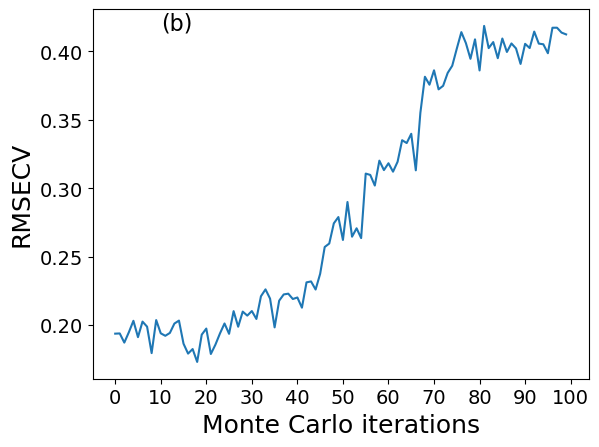

In [30]:
import numpy as np
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
import random
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import copy
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings(action='ignore')  # 忽略告警

def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        PRESS :各主成分数对应的PRESS
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1,scale=False)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex

def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
            RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc,scale=False)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean
def CARS_Cloud(X, y, N=100, f=20, cv=10):
    p = 0.8
    m, n = X.shape
    u = np.power((n/2), (1/(N-1)))
    k = (1/(N-1)) * np.log(n/2)
    cal_num = np.round(m * p)
    # val_num = m - cal_num
    b2 = np.arange(n)
    x = copy.deepcopy(X)
    D = np.vstack((np.array(b2).reshape(1, -1), X))
    WaveData = []
    # Coeff = []
    WaveNum =[]
    RMSECV = []
    r = []
    for i in range(1, N+1):
        r.append(u*np.exp(-1*k*i))
        # r = np.cbrt(u * np.exp(-1 * k * np.arange(1, N+1)))   #3次方根
        wave_num = int(np.round(r[i-1]*n))
        WaveNum = np.hstack((WaveNum, wave_num))
        cal_index = np.random.choice    \
            (np.arange(m), size=int(cal_num), replace=False)
        wave_index = b2[:wave_num].reshape(1, -1)[0]
        xcal = x[np.ix_(list(cal_index), list(wave_index))]
        #xcal = xcal[:,wave_index].reshape(-1,wave_num)
        ycal = y[cal_index]
        x = x[:, wave_index]
        D = D[:, wave_index]
        d = D[0, :].reshape(1,-1)
        wnum = n - wave_num
        if wnum > 0:
            d = np.hstack((d, np.full((1, wnum), -1)))
        if len(WaveData) == 0:
            WaveData = d
        else:
            WaveData  = np.vstack((WaveData, d.reshape(1, -1)))

        if wave_num < f:
            f = wave_num

        pls = PLSRegression(n_components=f,scale=False)
        pls.fit(xcal, ycal)
                # # beta = pls.coef_
        
        # Get VIP scores
        W = pls.x_weights_
        T = pls.x_scores_
        P = pls.x_loadings_
        Q = pls.y_loadings_
        V = np.dot(np.dot(P, np.diag(1/np.diag(np.dot(P.T, P)))), P.T)
        V = np.dot(V, W)
        s = np.diag(np.dot(np.dot(T.T, T), np.dot(W.T, W)))
        s_vip = np.sqrt(len(s)*s/np.sum(s))
        # s_vip = len(s)*s/np.sum(s)
        vip_scores = np.dot(V, s_vip)
        beta = vip_scores
        

        coef = copy.deepcopy(beta)
        # b = np.abs(beta)
        b = beta

        b2 = np.argsort(-b, axis=0)
        coef = copy.deepcopy(beta)
        coeff = coef[b2].reshape(len(b2), -1)
        # cb = coeff[:wave_num]
        #
        # if wnum > 0:
        #     cb = np.vstack((cb, np.full((wnum, 1), -1)))
        # if len(Coeff) == 0:
        #     Coeff = copy.deepcopy(cb)
        # else:
        #     Coeff = np.hstack((Coeff, cb))
        
        rmsecv, rindex = PC_Cross_Validation(xcal, ycal, f, cv)
        RMSECV.append(Cross_Validation(xcal, ycal, rindex+1, cv))
    # CoeffData = Coeff.T

    WAVE = []
    # COEFF = []

    for i in range(WaveData.shape[0]):
        wd = WaveData[i, :]
        # cd = CoeffData[i, :]
        WD = np.ones((len(wd)))
        # CO = np.ones((len(wd)))
        for j in range(len(wd)):
            ind = np.where(wd == j)
            if len(ind[0]) == 0:
                WD[j] = 0
                # CO[j] = 0
            else:
                WD[j] = wd[ind[0]]
                # CO[j] = cd[ind[0]]
        if len(WAVE) == 0:
            WAVE = copy.deepcopy(WD)
        else:
            WAVE = np.vstack((WAVE, WD.reshape(1, -1)))
        # if len(COEFF) == 0:
        #     COEFF = copy.deepcopy(CO)
        # else:
        #     COEFF = np.vstack((WAVE, CO.reshape(1, -1)))
    #print(WaveData)
    #print(WAVE)
    MinIndex = np.argmin(RMSECV)
    Optimal = WAVE[MinIndex, :]
    boindex = np.where(Optimal != 0)
    OptWave = boindex[0]
    OptWave=np.array(OptWave)
    OptWave=list(OptWave)
    
    print(str(MinIndex))
    
    fig = plt.figure()
    fonts = 18
    # plt.subplot(211)
    # plt.figure(figsize=(8, 6))
    # plt.text(10, 188, "(a)\n\n", fontsize=16, color='black') 
    # # 设置刻度的间隔为每隔10一个刻度
    # x_ticks = np.arange(0, N+10, 10)
    # plt.xticks(x_ticks,fontsize=18)
    # plt.yticks(fontsize=18)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    # plt.ylabel('The number of wavelengths selected', fontsize=fonts)
    # # plt.title('The optimal number of iterations:' + str(MinIndex) + 'times', fontsize=fonts)
    # plt.title('The optimal number of iterations:' + '40' + 'times', fontsize=fonts)
    # plt.plot(np.arange(N), WaveNum)
    
    plt.text(10, 0.9 * max(RMSECV), "(b)\n\n", fontsize=16, color='black') 
    # plt.subplot(212)
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('RMSECV', fontsize=fonts)
    plt.plot(np.arange(N), RMSECV)

    # plt.subplot(313)
    # plt.xlabel('蒙特卡洛迭代次数', fontsize=fonts)
    # plt.ylabel('各变量系数值', fontsize=fonts)
    # plt.plot(COEFF)
    # plt.vlines(MinIndex, -1e3, 1e3, colors='r')
    # plt.show()
    return OptWave, RMSECV

import pandas as pd
# data=pd.read_excel(r"/Users/macbook/Documents/data/DD可见-近红外.xlsx").values
data=pd.read_excel(r"/Users/macbook/Documents/data/FL199.xlsx").values

if __name__ == "__main__":
    y = data[:,0]
    X = data[:,1:]
    cars_index, RMSECV=CARS_Cloud(X, y)






In [31]:
min(RMSECV)

0.17309904454432398

In [32]:
RMSECV

[0.19373808107103316,
 0.19389653632742826,
 0.18720412207782847,
 0.19478039542516684,
 0.20312262351624746,
 0.19119297997312384,
 0.2025419315696923,
 0.19883990732097867,
 0.17953654495469493,
 0.20365653414543994,
 0.19398572829626073,
 0.1921785582987253,
 0.1942527525388389,
 0.2011142482564579,
 0.20327237520533264,
 0.18641550588788905,
 0.17917740355470557,
 0.18250094063307573,
 0.17309904454432398,
 0.19301676972584808,
 0.19745427021027273,
 0.17889296348747022,
 0.1856866732750207,
 0.19386866192665902,
 0.201169384606321,
 0.1936167961009063,
 0.21017116909393202,
 0.198795072184749,
 0.2098338330086466,
 0.20692109381390714,
 0.2102537630377311,
 0.20446944868175926,
 0.221046941845142,
 0.22607570098321358,
 0.21932340656106764,
 0.19832610119989907,
 0.2178170403656193,
 0.22238179262887167,
 0.22292500264498444,
 0.21904231837976043,
 0.2201473542556482,
 0.21271184045047167,
 0.23118578141025087,
 0.23186532201513677,
 0.22595520952219453,
 0.23744761831117844,
 0.2

In [33]:
print(len(cars_index))
print(cars_index)

94
[1, 2, 3, 4, 5, 6, 126, 127, 132, 133, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 219, 220, 221, 222, 223]
